<a href="https://colab.research.google.com/github/phornkanok00/GE338-Data-Science/blob/main/Lab4_Geographic_Modeling/Lab4_Geograhic_Modeling_6606614763.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.3 MB/s eta 0:00:00


In [2]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='ee-phornkanok')

In [4]:

# พื้นที่ศึกษา: เชียงใหม่
roi = ee.FeatureCollection('FAO/GAUL/2015/level1') \
    .filter(ee.Filter.eq('ADM1_NAME', 'Chiang Mai'))

Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(roi, {'color': 'red'}, 'Chiang Mai Boundary')
# ช่วงเวลาวิเคราะห์ (ฤดูไฟป่า 2024)
start_24 = '2024-01-01'
end_24 = '2024-05-31'

# ---------------------------------------------------------
# STEP 1: เตรียมปัจจัย
# ---------------------------------------------------------

# A. Heat (ความร้อน) - LST
lst = ee.ImageCollection('MODIS/061/MOD11A1') \
    .filterDate(start_24, end_24).select('LST_Day_1km').median().clip(roi)
lst_norm = lst.unitScale(13000, 16000).clamp(0, 1)

# B. Fuel Density (ความหนาแน่นเชื้อเพลิง) - ใช้ NDVI
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterDate(start_24, end_24).filterBounds(roi) \
    .filter(ee.Filter.lt('CLOUD_COVER', 30)).median().clip(roi)
ndvi = l8.normalizedDifference(['SR_B5', 'SR_B4'])
fuel_density_norm = ndvi.unitScale(0, 0.8).clamp(0, 1) # ยิ่งเขียวยิ่งมีเชื้อเพลิงเยอะ

# C. Fuel Dryness (ความแห้งของเชื้อเพลิง) - เปลี่ยนจาก NDVI เป็น NDMI
ndmi = l8.normalizedDifference(['SR_B5', 'SR_B6'])
# ยิ่งแห้ง (NDMI ต่ำ) → เสี่ยงสูง
dryness_norm = ndmi.unitScale(-0.5, 0.5).subtract(1).multiply(-1).clamp(0, 1)

# D. History (ประวัติไฟ)
history = ee.ImageCollection('FIRMS') \
    .filterDate('2022-01-01', '2023-12-31').select('T21').count().clip(roi)
history_norm = history.unitScale(0, 5).clamp(0, 1)

# ---------------------------------------------------------
# STEP 2: รวมโมเดลด้วย AHP Weights (รวมกันได้ 1.0 พอดี)
# ---------------------------------------------------------
risk = dryness_norm.multiply(0.25) \
       .add(lst_norm.multiply(0.30)) \
       .add(fuel_density_norm.multiply(0.23)) \
       .add(history_norm.multiply(0.22)) \
       .rename('Fire_Risk')

# ---------------------------------------------------------
# STEP 3: แสดงผล
# ---------------------------------------------------------

# 1. แผนที่ Risk Score
Map.addLayer(risk, {
    'min': 0.2, 'max': 0.6,
    'palette': ['blue', 'green', 'yellow', 'orange', 'red']
}, '1. Risk Score (AHP)')

# 2. แผนที่แบ่งเกณฑ์ (ปรับ Threshold ให้นิ่งขึ้น)
risk_class_new = ee.Image(1) \
    .where(risk.gt(0.30), 2) \
    .where(risk.gt(0.40), 3) \
    .clip(roi)
Map.addLayer(risk_class_new, {
    'min': 1, 'max': 3,
    'palette': ['green', 'orange', 'red']
}, '2. Risk Levels (Green-Orange-Red)')

# 3. จุดไฟจริงปี 2024 (สำหรับการดูด้วยตา)
fire_actual_img = ee.ImageCollection('FIRMS') \
    .filterDate(start_24, end_24).select('T21').count().clip(roi)
Map.addLayer(fire_actual_img.gt(0).selfMask(), {'palette': ['purple']}, '3. Actual Hotspots 2024')

Map.addLayerControl()
Map

Map(center=[18.792236850995966, 98.73204090284445], controls=(WidgetControl(options=['position', 'transparent_…

In [17]:
# -------------------------
# Export Risk Class
# -------------------------
task_class = ee.batch.Export.image.toDrive(
    image=risk_class_new,
    description='ChiangMai_FireRiskClass_2024',
    folder='GE338',
    fileNamePrefix='ChiangMai_FireRiskClass_2024',
    region=roi.geometry(),
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13
)
task_class.start()

print("Export tasks started!")

Export tasks started!


In [27]:
# =======================================================
# Sensitivity Analysis: Heat (LST) ±20%
# =======================================================

# Baseline Risk (สมดุลตาม Feature Importance)
risk_baseline = dryness_norm.multiply(0.25) \
    .add(lst_norm.multiply(0.30)) \
    .add(fuel_density_norm.multiply(0.23)) \
    .add(history_norm.multiply(0.22)) \
    .rename('Fire_Risk')

# Heat +20% (0.30 -> 0.36)
risk_plus_20 = dryness_norm.multiply(0.24) \
    .add(lst_norm.multiply(0.36)) \
    .add(fuel_density_norm.multiply(0.23)) \
    .add(history_norm.multiply(0.17)) \
    .rename('Fire_Risk')

# Heat -20% (0.30 -> 0.24)
risk_minus_20 = dryness_norm.multiply(0.26) \
    .add(lst_norm.multiply(0.24)) \
    .add(fuel_density_norm.multiply(0.23)) \
    .add(history_norm.multiply(0.27)) \
    .rename('Fire_Risk')

# =======================================================
# สร้าง Map ใหม่ทุกครั้งเพื่อล้างเลเยอร์เก่า
# =======================================================
Map = geemap.Map()
Map.centerObject(roi, 9)

# ------------------------------
# เพิ่ม Layer Risk
# ------------------------------
Map.addLayer(risk_baseline, {'min':0.2,'max':0.6,'palette':['white','orange']}, 'Baseline Risk')
Map.addLayer(risk_plus_20, {'min':0.2,'max':0.6,'palette':['white','red']}, 'Heat +20%')
Map.addLayer(risk_minus_20, {'min':0.2,'max':0.6,'palette':['white','blue']}, 'Heat -20%')

# ------------------------------
# Highlight Robust / Sensitive Areas
# ------------------------------
diff_plus  = risk_plus_20.subtract(risk_baseline).abs()
diff_minus = risk_minus_20.subtract(risk_baseline).abs()
robust = diff_plus.lt(0.05).And(diff_minus.lt(0.05))
sensitive = robust.Not()

Map.addLayer(robust.updateMask(robust), {'palette':['green']}, 'Robust Areas')
Map.addLayer(sensitive.updateMask(sensitive), {'palette':['purple']}, 'Sensitive Areas')

# แสดง Map
Map

Map(center=[18.79223685099598, 98.7320409028442], controls=(WidgetControl(options=['position', 'transparent_bg…

In [10]:
#validation
# -----------------------------
# ROI: Chiang Mai
# -----------------------------
roi = ee.FeatureCollection('FAO/GAUL/2015/level1') \
    .filter(ee.Filter.eq('ADM1_NAME', 'Chiang Mai'))

# -----------------------------
# Load existing Risk Map (risk_class: 1-3)
# -----------------------------
# สมมติคุณสร้าง risk_class ไว้แล้วในโค้ดเดิม
# risk_class = ...

# -----------------------------
# 1. Load MODIS Burned Area 2024
# -----------------------------
modis_ba = ee.ImageCollection('MODIS/061/MCD64A1') \
    .filterDate('2024-01-01', '2024-12-31') \
    .select('BurnDate')

# สร้าง mask: pixel > 0 = burned
burned_mask = modis_ba.max().gt(0).selfMask()

# -----------------------------
# 2. ตรวจสอบพื้นที่เสี่ยงกับ Burned Area
# -----------------------------
high_risk = risk_class_new.gte(2)  # พื้นที่เสี่ยงระดับ 2-3
correct_burn = burned_mask.updateMask(high_risk)

# -----------------------------
# 3. คำนวณ Accuracy
# -----------------------------
total_burned = burned_mask.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=500,
    maxPixels=1e13
).get('BurnDate').getInfo()

correct_burned = correct_burn.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=500,
    maxPixels=1e13
).get('BurnDate').getInfo()

burned_accuracy = (correct_burned / total_burned) * 100

print("\n--- MODIS Burned Area Validation ---")
print(f"Total burned pixels: {total_burned}")
print(f"Correctly predicted burned pixels: {correct_burned}")
print(f"Burned Area Accuracy (%): {burned_accuracy:.2f}%")

# =======================================================
# สร้าง Map ใหม่ทุกครั้งเพื่อล้างเลเยอร์เก่า
# =======================================================
Map = geemap.Map()
Map.centerObject(roi, 9)
# -----------------------------
# 4. Visualization (optional)
# -----------------------------
Map = geemap.Map(center=[19, 99.3], zoom=9)
Map.addLayer(burned_mask, {'palette':'black'}, 'MODIS Burned Area 2024')
Map.addLayer(correct_burn, {'palette':'blue'}, 'Correctly Predicted Burn Area')
Map.addLayer(roi, {'color':'red'}, 'Chiang Mai Boundary')
Map.addLayerControl()
Map


--- MODIS Burned Area Validation ---
Total burned pixels: 2847.035294117648
Correctly predicted burned pixels: 1481.286274509804
Burned Area Accuracy (%): 52.03%


Map(center=[19, 99.3], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(ch…

Dryness Focus: Mean Risk = 0.458
Heat Focus: Mean Risk = 0.539
Fuel Density Focus: Mean Risk = 0.424
History Focus: Mean Risk = 0.412


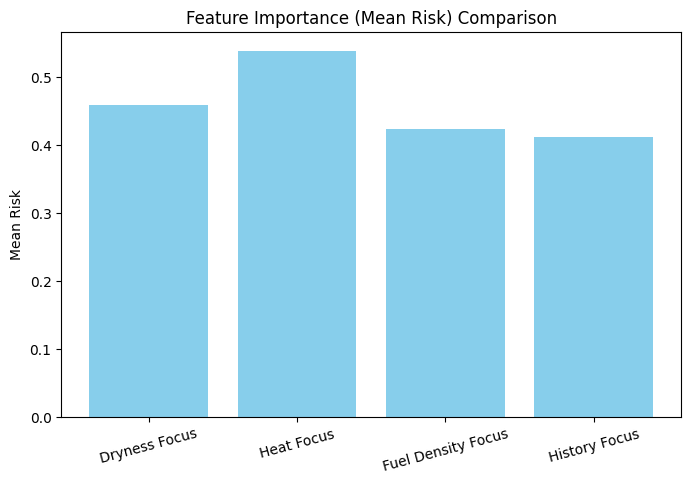

In [22]:
import ee
import geemap
import matplotlib.pyplot as plt


# ------------------------------
# ROI: เชียงใหม่
# ------------------------------
roi = ee.FeatureCollection('FAO/GAUL/2015/level1') \
    .filter(ee.Filter.eq('ADM1_NAME', 'Chiang Mai'))

Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(roi, {'color': 'red'}, 'Chiang Mai Boundary')

# ------------------------------
# STEP 0: ช่วงเวลาวิเคราะห์ (ฤดูไฟป่า 2024)
# ------------------------------
start_24 = '2024-01-01'
end_24 = '2024-05-31'

# ------------------------------
# STEP 1: เตรียมปัจจัย
# ------------------------------

# A. Heat (LST)
lst = ee.ImageCollection('MODIS/061/MOD11A1') \
    .filterDate(start_24, end_24).select('LST_Day_1km').median().clip(roi)
lst_norm = lst.unitScale(13000, 16000).clamp(0, 1)

# B. Fuel Density (NDVI)
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterDate(start_24, end_24).filterBounds(roi) \
    .filter(ee.Filter.lt('CLOUD_COVER', 30)).median().clip(roi)
ndvi = l8.normalizedDifference(['SR_B5', 'SR_B4'])
fuel_density_norm = ndvi.unitScale(0, 0.8).clamp(0, 1)

# C. Fuel Dryness (NDMI)
ndmi = l8.normalizedDifference(['SR_B5', 'SR_B6'])
dryness_norm = ndmi.unitScale(-0.5, 0.5).subtract(1).multiply(-1).clamp(0, 1)

# D. History (ไฟปี 2022-2023)
history = ee.ImageCollection('FIRMS') \
    .filterDate('2022-01-01', '2023-12-31').select('T21').count().clip(roi)
history_norm = history.unitScale(0, 5).clamp(0, 1)

# ------------------------------
# STEP 2: Scenario น้ำหนัก
# ------------------------------
scenarios = {
    'Dryness Focus': [0.50, 0.20, 0.20, 0.10],
    'Heat Focus': [0.20, 0.50, 0.20, 0.10],
    'Fuel Density Focus': [0.20, 0.20, 0.50, 0.10],
    'History Focus': [0.20, 0.20, 0.10, 0.50]
}

# ------------------------------
# STEP 3: คำนวณ Mean Risk สำหรับแต่ละ scenario (แก้ชื่อ band)
# ------------------------------
results = {}

for name, w in scenarios.items():
    # รวมปัจจัยเป็น risk map
    risk = dryness_norm.multiply(w[0]) \
        .add(lst_norm.multiply(w[1])) \
        .add(fuel_density_norm.multiply(w[2])) \
        .add(history_norm.multiply(w[3])) \
        .rename('risk')   # <- ตั้งชื่อ band เป็น 'risk'

    # ค่าเฉลี่ย risk ใน ROI
    mean_risk = risk.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=1000,
        maxPixels=1e10
    ).getInfo()

    # ใช้ key 'risk' แทน 'constant'
    results[name] = mean_risk.get('risk', 0)
    print(f"{name}: Mean Risk = {results[name]:.3f}")

# ------------------------------
# STEP 4: Plot Bar Chart
# ------------------------------
names = list(results.keys())
means = [results[n] for n in names]

plt.figure(figsize=(8,5))
plt.bar(names, means, color='skyblue')
plt.ylabel('Mean Risk')
plt.title('Feature Importance (Mean Risk) Comparison')
plt.xticks(rotation=15)
plt.show()
